# CSC 591 - IoT Analytics: Project 2
## Task 3 - Data Visualization

**Dataset:** Daily weather observations from Raleigh-Durham International Airport    
**Full dataset used:** 1,477 clean rows

| Variable | Description | Unit |
|----------|-------------|------|
| X1 | TMAX — Max daily temperature | °F |
| X2 | TMIN — Min daily temperature | °F |
| X3 | PRCP — Daily precipitation | inches |
| X4 | AWND — Avg wind speed | mph |
| X5 | SNOW — Daily snowfall | inches |
| Y  | TAVG — Avg daily temperature **(output)** | °F |

In [5]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Load full dataset 
df = pd.read_csv('weather_clean.csv')

variables = ['X1', 'X2', 'X3', 'X4', 'X5']
labels = {
    'X1': 'TMAX — Max Temp (°F)',
    'X2': 'TMIN — Min Temp (°F)',
    'X3': 'PRCP — Precipitation (in)',
    'X4': 'AWND — Avg Wind Speed (mph)',
    'X5': 'SNOW — Snowfall (in)'
}

print(f'Full dataset: {len(df)} rows')
df.describe().round(2)

Full dataset: 1477 rows


,X1,X2,X3,X4,X5,Y
count,1477.00,1477.00,1477.00,1477.00,1477.00,1477.0
mean,73.82,52.23,0.13,5.90,0.01,62.6
std,15.51,15.87,0.36,2.89,0.09,15.0
min,29.00,10.00,0.00,0.45,0.00,19.0
25%,63.00,39.00,0.00,3.80,0.00,51.0
50%,75.00,54.00,0.00,5.37,0.00,65.0
75%,86.00,66.00,0.03,7.61,0.00,75.0
max,106.00,80.00,4.02,19.91,2.30,89.0


## Task 3.1 - Boxplots for Each Variable Xi

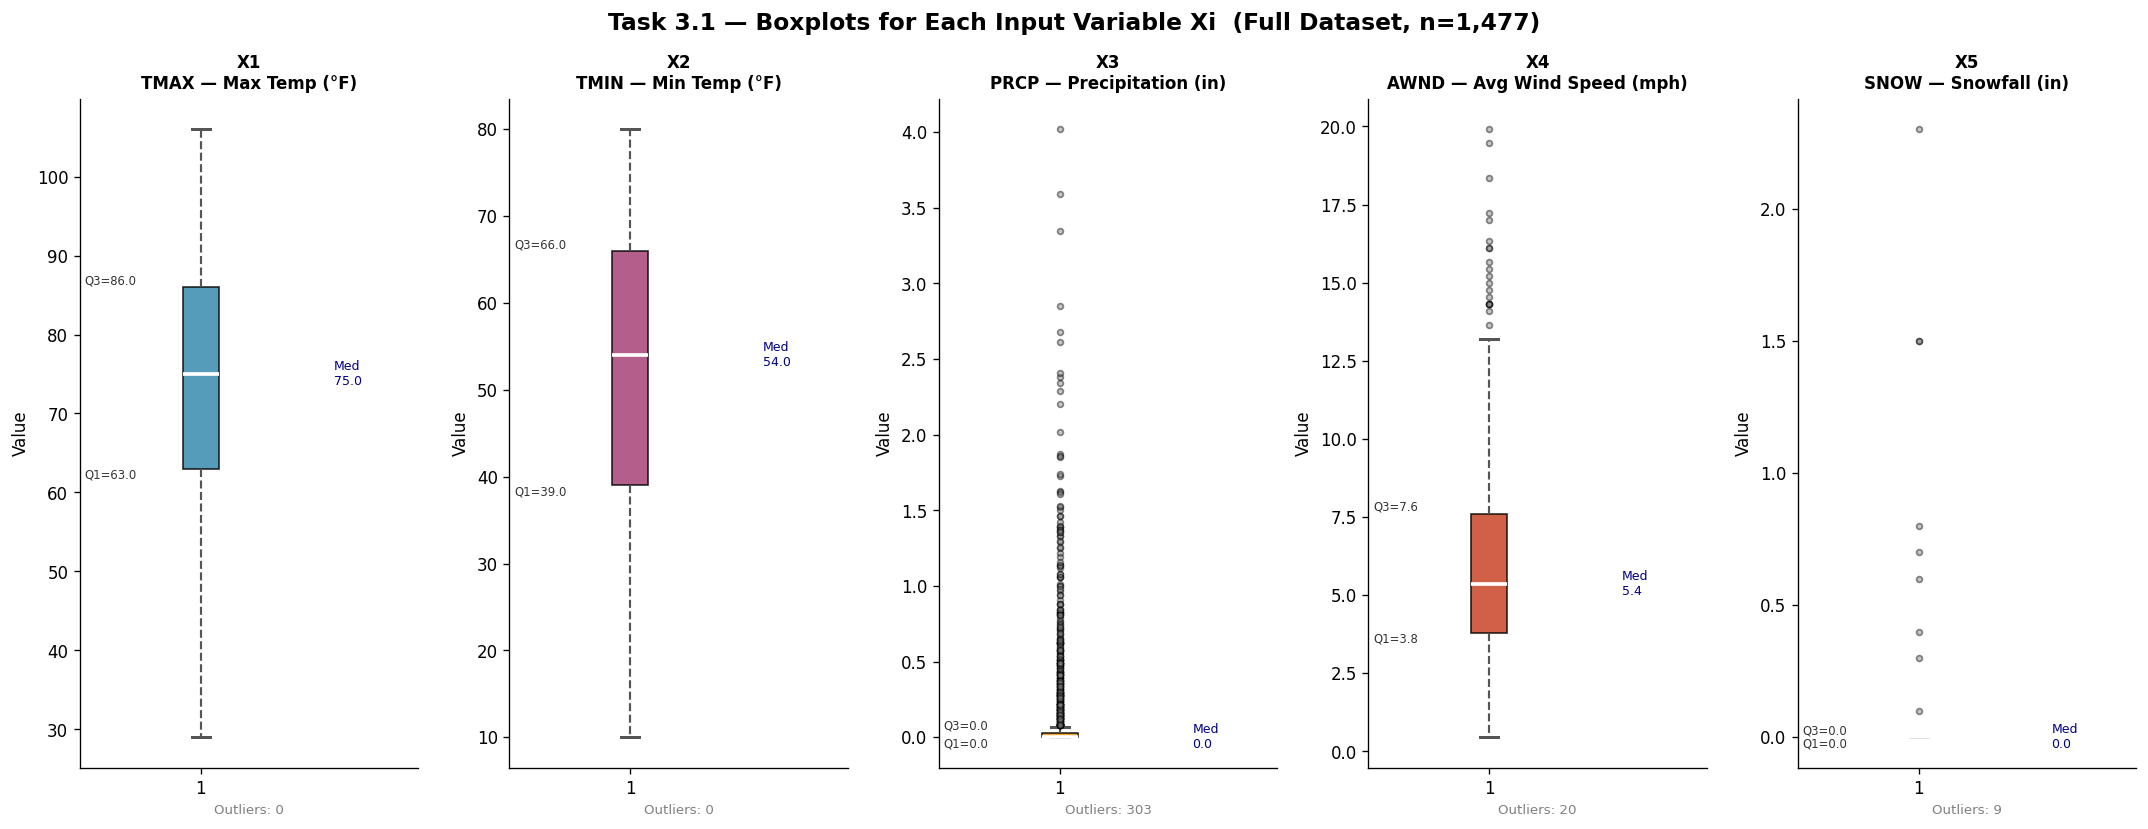

Saved: boxplots.png


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(18, 7))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

for i, col in enumerate(variables):
    bp = axes[i].boxplot(
        df[col].dropna(),
        patch_artist=True,
        medianprops  = dict(color='white', linewidth=2.2),
        whiskerprops = dict(color='#555555', linewidth=1.3, linestyle='--'),
        capprops     = dict(color='#555555', linewidth=1.8),
        flierprops   = dict(marker='o', markerfacecolor='gray',
                            markersize=3.5, alpha=0.45, linestyle='none')
    )
    bp['boxes'][0].set_facecolor(colors[i])
    bp['boxes'][0].set_alpha(0.82)

    # Key stats annotations
    med = df[col].median()
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    n_out = df[col][(df[col] < q1 - 1.5*(q3-q1)) | (df[col] > q3 + 1.5*(q3-q1))].count()

    axes[i].set_title(f'{col}\n{labels[col]}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Value')
    axes[i].set_xlim(0.5, 1.9)
    axes[i].text(1.55, med, f'Med\n{med:.1f}', va='center', fontsize=7.5, color='navy')
    axes[i].text(0.52, q3,  f'Q3={q3:.1f}', va='bottom', fontsize=7, color='#333')
    axes[i].text(0.52, q1,  f'Q1={q1:.1f}', va='top',    fontsize=7, color='#333')
    axes[i].set_xlabel(f'Outliers: {n_out}', fontsize=8, color='gray')

fig.suptitle('Task 3.1 — Boxplots for Each Input Variable Xi  (Full Dataset, n=1,477)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: boxplots.png')

## Task 3.2 - Scatter Plots: Y vs Each Variable Xi

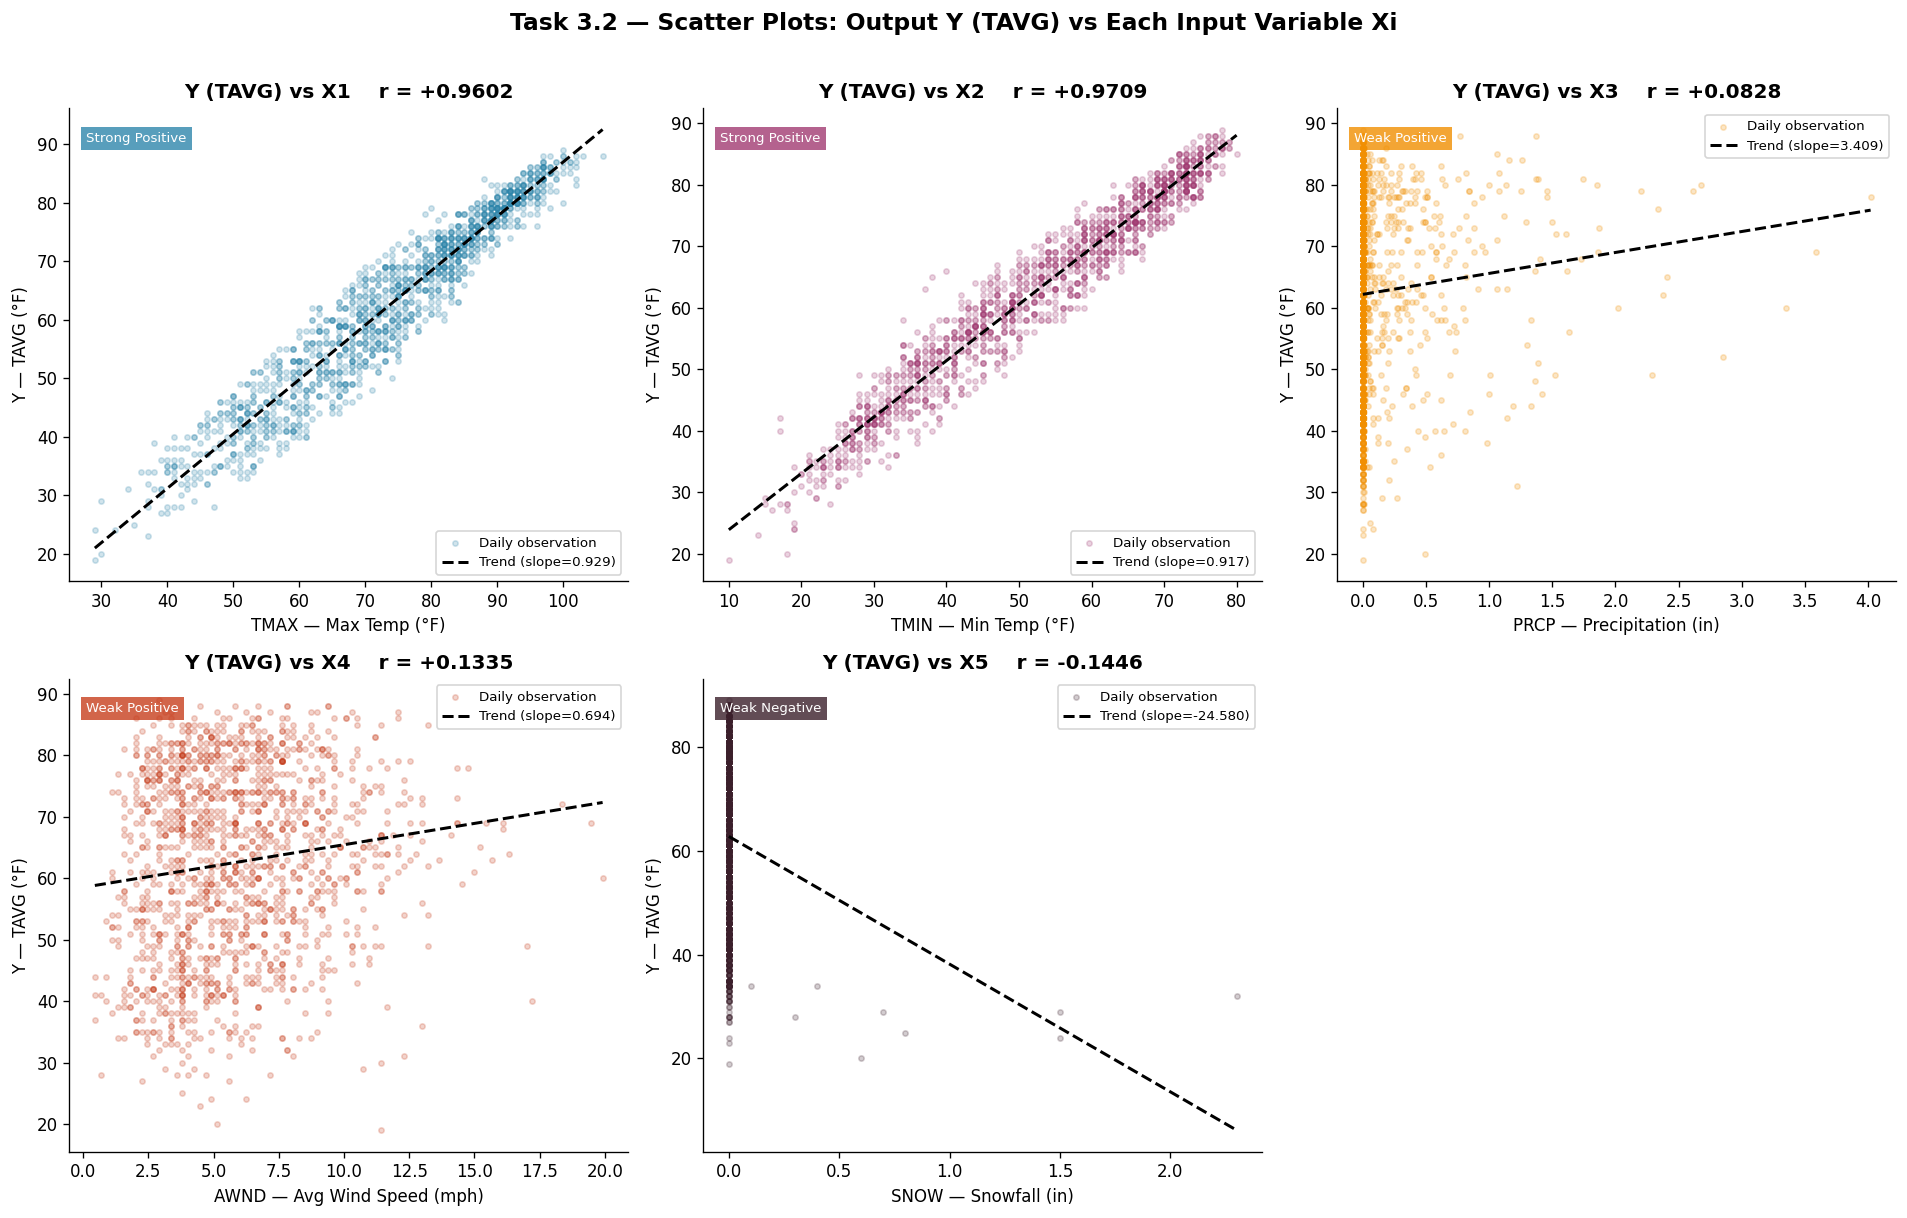

Saved: scatter_plots.png

Correlation Summary:
Variable    r value  Direction & Strength
──────────────────────────────────────────────────
X1           0.9602  Strong Positive
X2           0.9709  Strong Positive
X3           0.0828  Weak Positive
X4           0.1335  Weak Positive
X5          -0.1446  Weak Negative


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

for i, col in enumerate(variables):
    x = df[col]
    y = df['Y']
    mask = (~x.isna()) & (~y.isna())

    # Scatter
    axes[i].scatter(x[mask], y[mask], alpha=0.22, s=10,
                    color=colors[i], label='Daily observation')

    # Linear trend line
    coeffs = np.polyfit(x[mask], y[mask], 1)
    x_range = np.linspace(x.min(), x.max(), 300)
    axes[i].plot(x_range, np.polyval(coeffs, x_range),
                 color='black', linewidth=1.8, linestyle='--',
                 label=f'Trend (slope={coeffs[0]:.3f})')

    # Correlation coefficient
    r = np.corrcoef(x[mask], y[mask])[0, 1]
    axes[i].set_title(f'Y (TAVG) vs {col}    r = {r:+.4f}', fontweight='bold')
    axes[i].set_xlabel(labels[col])
    axes[i].set_ylabel('Y — TAVG (°F)')
    axes[i].legend(fontsize=8)

    # r label box
    strength = 'Strong' if abs(r) > 0.8 else 'Moderate' if abs(r) > 0.4 else 'Weak'
    direction = 'Positive' if r > 0 else 'Negative'
    axes[i].text(0.03, 0.95, f'{strength} {direction}',
                 transform=axes[i].transAxes, fontsize=8,
                 color='white', va='top',
                 bbox=dict(facecolor=colors[i], alpha=0.8, pad=3, edgecolor='none'))

axes[5].set_visible(False)
fig.suptitle('Task 3.2 — Scatter Plots: Output Y (TAVG) vs Each Input Variable Xi',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: scatter_plots.png')

# Print correlation summary
print('\nCorrelation Summary:')
print(f'{"Variable":<8} {"r value":>10}  Direction & Strength')
print('─'*50)
for col in variables:
    mask = (~df[col].isna()) & (~df['Y'].isna())
    r = np.corrcoef(df[col][mask], df['Y'][mask])[0,1]
    strength = 'Strong' if abs(r) > 0.8 else 'Moderate' if abs(r) > 0.4 else 'Weak'
    direction = 'Positive' if r > 0 else 'Negative'
    print(f'{col:<8} {r:>10.4f}  {strength} {direction}')

## Task 3.3 - Density Curve of Output Variable Y (TAVG)

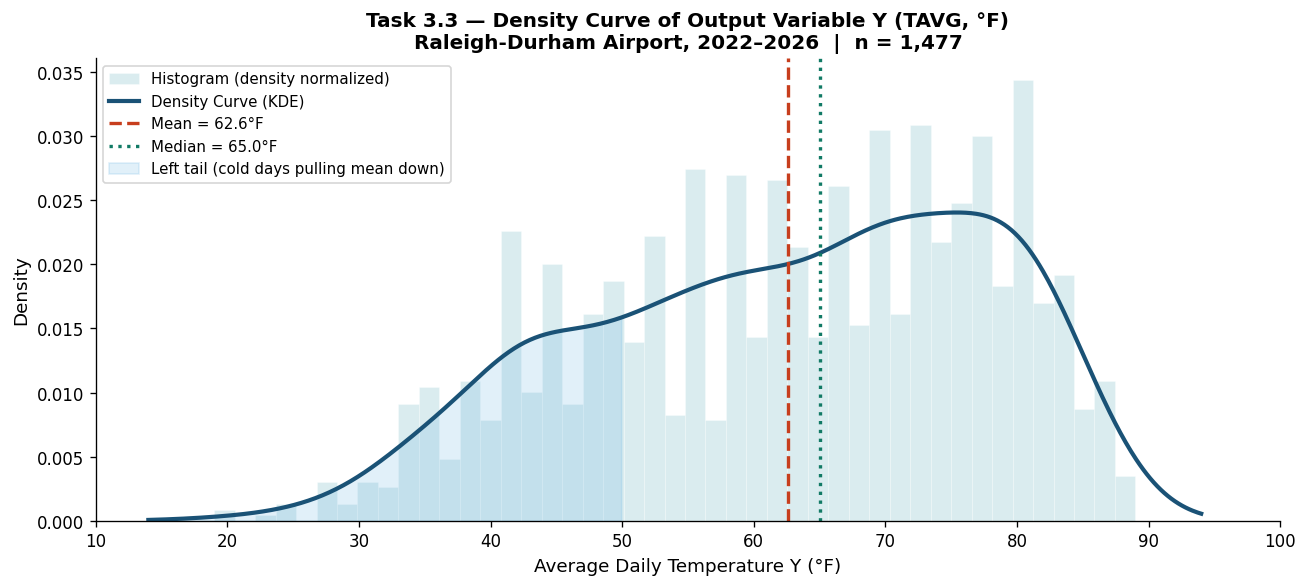

Saved: density_curve.png

Y stats: mean=62.60, median=65.00
Since mean (62.60) < median (65.00) => LEFT-SKEWED distribution


In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

y_vals = df['Y'].dropna().values
y_mean   = np.mean(y_vals)
y_median = np.median(y_vals)

# Histogram backdrop (normalized to density)
ax.hist(y_vals, bins=45, density=True,
        color='#AED6DC', alpha=0.45, edgecolor='white', linewidth=0.4,
        label='Histogram (density normalized)')

# KDE density curve
kde    = gaussian_kde(y_vals, bw_method='silverman')
x_rng  = np.linspace(y_vals.min() - 5, y_vals.max() + 5, 600)
ax.plot(x_rng, kde(x_rng), color='#1A5276', linewidth=2.5, label='Density Curve (KDE)')

# Mean and median lines
ax.axvline(y_mean,   color='#C73E1D', linestyle='--', linewidth=2,
           label=f'Mean = {y_mean:.1f}°F')
ax.axvline(y_median, color='#117A65', linestyle=':',  linewidth=2,
           label=f'Median = {y_median:.1f}°F')

# Shade left tail (skew region)
ax.fill_between(x_rng, kde(x_rng),
                where=(x_rng < 50), alpha=0.18, color='#5DADE2',
                label='Left tail (cold days pulling mean down)')

ax.set_title(
    'Task 3.3 — Density Curve of Output Variable Y (TAVG, °F)\n'
    'Raleigh-Durham Airport, 2022–2026  |  n = 1,477',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Average Daily Temperature Y (°F)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(10, 100)

plt.tight_layout()
plt.savefig('density_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: density_curve.png')
print(f'\nY stats: mean={y_mean:.2f}, median={y_median:.2f}')
print(f'Since mean ({y_mean:.2f}) < median ({y_median:.2f}) => LEFT-SKEWED distribution')

## Task 3.4 - Analysis and Interpretation

### Boxplot Analysis (Task 3.1)

The five boxplots reveal sharply contrasting distributional profiles across the input variables. **X1 (TMAX)** and **X2 (TMIN)** both show wide, roughly symmetric boxes with large IQRs (23°F for TMAX, 27°F for TMIN across the full dataset), reflecting the full annual temperature cycle at Raleigh-Durham. Their median lines sit near the center of each box, confirming that temperature data is approximately symmetric over a full year. Neither variable has a significant number of boxplot outlier points, as temperature is physically bounded and seasonal variation is smooth.

**X3 (PRCP)** and **X5 (SNOW)** present the starkest contrast — both have boxes collapsed near zero, with long upper whiskers and dense clusters of outlier dots in the upper tail. For X3, the outlier dots represent heavy rainfall events (tropical remnants, frontal systems), while for X5 the dots represent the handful of snowfall events that occur each year in Raleigh. The near-zero box confirms that the dominant experience on any given day is no precipitation and no snow. **X4 (AWND)** shows a moderately right-skewed box with a compact IQR and a small number of high-wind outliers at the top, corresponding to storm-driven wind events.

---

### Scatter Plot Analysis (Task 3.2)

The scatter plots reveal a clear hierarchy in how strongly each variable relates to Y (TAVG):

**X1 (TMAX) vs Y: r = +0.9602** — the strongest relationship in the dataset. The scatter plot shows a tight, near-linear band from lower-left to upper-right. This is expected because average temperature is bounded between the daily minimum and maximum — TMAX directly defines the upper limit of Y. The trend line has a positive slope close to 0.5, consistent with Y ≈ (TMAX + TMIN)/2.

**X2 (TMIN) vs Y: r = +0.9709** — slightly stronger than X1. Again near-perfectly linear, confirming TMIN is the single strongest predictor of TAVG. Cold nights force the average down and warm nights bring it up. Together, X1 and X2 almost completely explain Y — their combined information essentially equals TAVG arithmetically.

**X3 (PRCP) vs Y: r = +0.0828** — very weak positive relationship. The scatter plot is a near-vertical cloud with almost no visible trend. The slight positive slope arises because in Raleigh's climate, the rainiest days tend to occur during warm fronts and summer storms rather than cold dry winter days. The zero-inflation of X3 severely limits its linear correlation with Y.

**X4 (AWND) vs Y: r = +0.1335** — weak positive relationship. Contrary to the intuitive expectation that wind cools temperatures, the data shows a slightly positive trend. In Raleigh's dataset, the highest wind events occur during warm-season storm systems rather than cold arctic outflows, producing a net positive correlation. The scatter is very diffuse, confirming wind speed alone is a poor predictor of average temperature.

**X5 (SNOW) vs Y: r = −0.1446** — the only negative correlation. Snow events in Raleigh exclusively occur on the coldest days of the year, pulling Y sharply downward. Despite most values being zero, the few snow days cluster at the extreme low end of Y (TAVG as low as 19–25°F), creating a meaningful negative pull in the trend line. X5 is the only variable that carries a directionally negative relationship with Y.

---

### Density Curve Analysis (Task 3.3)

The density curve of Y (TAVG) reveals a **left-skewed, unimodal distribution** with a single dominant peak near 76°F. This shape is driven by Raleigh's climate: the warm season (May–September) spans approximately 5 months and produces consistently high TAVG values that create the peak, while winter months (December–February) produce a smaller number of cold days that form the left tail. Because summer is longer and more consistent than winter in Raleigh, the distribution is not bimodal — there is one dominant mode at the warm end.

The mean (62.60°F) is noticeably lower than the median (65.00°F), which is the defining signature of left skew: the cold winter days in the left tail pull the mean downward while the median remains closer to the warm-season peak. This means the mean understates the temperature a resident would experience on a typical day. The median (65°F) is a more accurate description of a "typical" day at Raleigh-Durham Airport.

The left tail (shaded blue, below 50°F) represents genuine winter cold days that are less frequent but statistically important. These cold days correspond to the snow events in X5 and the high-wind events in X4 that are the outliers in those variables. The density drops sharply above 85°F because summer temperatures at Raleigh-Durham are consistently warm but rarely extreme.

---

### Overall Reflection

The three visualization types together tell a complete and consistent story about this IoT weather dataset. The **boxplots** immediately identify which variables have symmetric vs. skewed distributions and flag outlier-prone variables (X3, X5) without requiring numerical analysis. The **scatter plots** directly answer the core IoT analytics question of which sensor inputs matter most for predicting the output — X1 and X2 dominate with near-perfect linear relationships, while X3, X4, and X5 contribute only weak secondary information. The **density curve** places all of this in seasonal context, showing that Y follows a left-skewed unimodal distribution where warm days are the norm and cold days are the exception.

A practical implication for IoT system design: if the goal is to predict or reconstruct TAVG, a sensor measuring only TMAX or TMIN would achieve very high accuracy (r > 0.96). Adding precipitation or wind speed sensors would contribute marginally. A snow sensor would add unique negative-direction information not captured by the other variables, but only for the rare cold events. This hierarchy of sensor importance — derived entirely from visualization — demonstrates the value of exploratory data analysis before building any predictive model.